[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/planetlabs/notebooks/blob/master/jupyter-notebooks/use_cases/large_area_utilities/large_area_utilities.ipynb)

# Split Large Areas into Manageable Bounding Boxes

The [Processing API](https://docs.planet.com/develop/apis/processing/) and [Statistical API](https://docs.planet.com/develop/apis/statistical/) accept a bounding box or geometry per request. When you work with a large area of interest (AOI), a single request may be too large to process efficiently. A common solution is to split the AOI into smaller bounding boxes and process each subarea separately.

This notebook shows how to use utilities in `sentinelhub` to split large areas into manageable parts for download, visualization, and analysis. For very large areas, the [Batch Processing API](https://docs.planet.com/develop/apis/batch-processing/) and [Batch Statistical API](https://docs.planet.com/develop/apis/batch-statistical/) handle the tiling on the server side. For installation and SDK details, see the [Sentinel Hub Python SDK](https://docs.planet.com/develop/sdks/#sentinel-hub-python-sdk) section in Planet documentation.

This notebook covers the following splitting strategies:

- [**Regular grid**](#Split-the-AOI-into-a-Regular-Grid) - divide the bounding box into equally sized cells
- [**OSM grid**](#Split-the-AOI-Using-the-OSM-Grid) - use the fixed OpenStreetMap tile grid
- [**Satellite tile boundaries**](#Split-the-AOI-Using-Satellite-Tile-Boundaries) - split along source satellite tiles
- [**Custom grid**](#Split-the-AOI-Using-a-Custom-Grid) - define your own grid from a list of bounding boxes
- [**UTM zones**](#Split-the-AOI-Across-UTM-Zones) - split by UTM zone or Military Grid Reference System
- [**Download example**](#Download-Data-for-Each-Bounding-Box) - download data for each subarea in parallel

## Prerequisites

### Imports

In [1]:
%matplotlib inline
import contextily as cx
import itertools
import tempfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon, box, shape

from sentinelhub import (
    CRS,
    BBox,
    BBoxSplitter,
    CustomGridSplitter,
    DataCollection,
    MimeType,
    MosaickingOrder,
    OsmSplitter,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    TileSplitter,
    UtmGridSplitter,
    UtmZoneSplitter,
)

In [ ]:
from sentinelhub import SHConfig

# Authenticate with the Sentinel Hub Python SDK; See docs: https://sentinelhub-py.readthedocs.io/en/latest/configure.html and https://docs.planet.com/develop/authentication
# If no default configuration detected, enter a client ID and secret to authenticate. These can be obtained by creating an OAuth client here: https://insights.planet.com/account
config = SHConfig()
if not config.sh_client_id or not config.sh_client_secret:
    from getpass import getpass
    print('No credentials found, please provide the OAuth client ID and secret.')
    config.sh_client_id = getpass('Client ID: ')
    config.sh_client_secret = getpass('Client Secret: ')
    ## Uncomment the following lines to save your credentials to a configuration
    # config.save() 
    # print(f'Credentials saved to {SHConfig.get_config_location()}')
else:
    print(f'Using credentials stored here: {SHConfig.get_config_location()}')

### Load the AOI

Start by defining the geometry for the area of interest. In this notebook, geometries are handled with `shapely`, so the AOI should be a `Polygon` or `MultiPolygon`.

This example uses the geometry of the [Hawaiian Islands](https://en.wikipedia.org/wiki/Hawaiian_Islands).

In [3]:
hawaii_area = shape({
    "type": "MultiPolygon",
    "coordinates": [
        [
            [
                [-155.634835, 18.948267],
                [-155.881297, 19.035898],
                [-155.919636, 19.123529],
                [-155.886774, 19.348084],
                [-156.062036, 19.73147],
                [-155.925113, 19.857439],
                [-155.826528, 20.032702],
                [-155.897728, 20.147717],
                [-155.87582, 20.26821],
                [-155.596496, 20.12581],
                [-155.284311, 20.021748],
                [-155.092618, 19.868393],
                [-155.092618, 19.736947],
                [-154.807817, 19.523346],
                [-154.983079, 19.348084],
                [-155.295265, 19.26593],
                [-155.514342, 19.134483],
                [-155.634835, 18.948267]
            ]
        ],
        [
            [
                [-156.587823, 21.029505],
                [-156.472807, 20.892581],
                [-156.324929, 20.952827],
                [-156.00179, 20.793996],
                [-156.051082, 20.651596],
                [-156.379699, 20.580396],
                [-156.445422, 20.60778],
                [-156.461853, 20.783042],
                [-156.631638, 20.821381],
                [-156.697361, 20.919966],
                [-156.587823, 21.029505]
            ]
        ],
        [
            [
                [-156.982162, 21.210244],
                [-157.080747, 21.106182],
                [-157.310779, 21.106182],
                [-157.239579, 21.221198],
                [-156.982162, 21.210244]
            ]
        ],
        [
            [
                [-157.951581, 21.697691],
                [-157.842042, 21.462183],
                [-157.896811, 21.325259],
                [-158.110412, 21.303352],
                [-158.252813, 21.582676],
                [-158.126843, 21.588153],
                [-157.951581, 21.697691]
            ]
        ],
        [
            [
                [-159.468693, 22.228955],
                [-159.353678, 22.218001],
                [-159.298908, 22.113939],
                [-159.33177, 21.966061],
                [-159.446786, 21.872953],
                [-159.764448, 21.987969],
                [-159.726109, 22.152277],
                [-159.468693, 22.228955]
            ]
        ]
    ]
})

type(hawaii_area)

shapely.geometry.multipolygon.MultiPolygon

The helper function below plots the AOI.

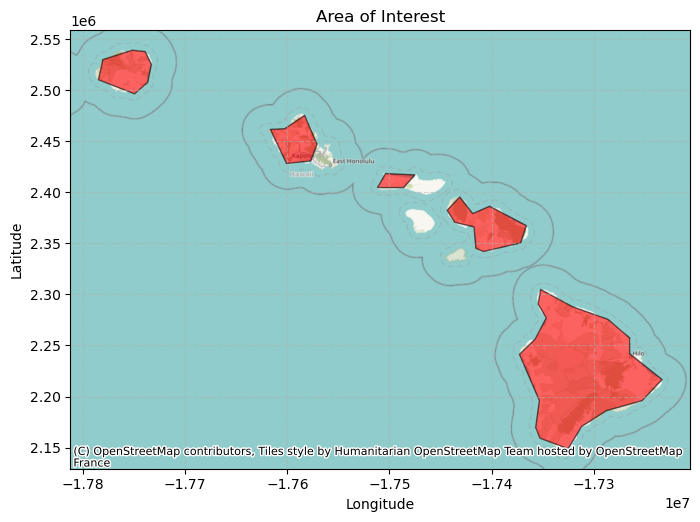

In [4]:
def show_area(area_shape):
    gs = gpd.GeoSeries([area_shape], crs="EPSG:4326")
    
    # Reproject to Web Mercator for basemap compatibility
    gs_wm = gs.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(8, 8))
    gs_wm.plot(ax=ax, facecolor="red", edgecolor="black", alpha=0.6)
    
    # Add OSM basemap
    cx.add_basemap(ax)

    ax.set_title("Area of Interest")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal')
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.show()


show_area(hawaii_area)

## Split the AOI

The next step is to split the AOI into smaller bounding boxes. These smaller areas can be easier to use in downstream requests and analysis workflows.

This notebook demonstrates several different splitting strategies.

In [5]:
bbox_splitter = BBoxSplitter(
    [hawaii_area], CRS.WGS84, (5, 4)
)  # bounding box will be split into grid of 5x4 bounding boxes

print("Area bounding box: {}\n".format(bbox_splitter.get_area_bbox().__repr__()))

bbox_list = bbox_splitter.get_bbox_list()
info_list = bbox_splitter.get_info_list()

print(
    "Each bounding box includes metadata about how it was created.\nExample:\nbbox: {}\ninfo: {}\n".format(
        bbox_list[0].__repr__(), info_list[0]
    )
)

Area bounding box: BBox(((-159.764448, 18.948267), (-154.807817, 22.228955)), crs=CRS('4326'))

Each bounding box includes metadata about how it was created.
Example:
bbox: BBox(((-159.764448, 21.408783), (-158.77312179999998, 22.228955)), crs=CRS('4326'))
info: {'parent_bbox': BBox(((-159.764448, 18.948267), (-154.807817, 22.228955)), crs=CRS('4326')), 'index_x': 0, 'index_y': 3}



You can also return the intersection geometry for each bounding box rather than just the bounding boxes themselves.

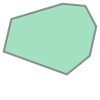

In [6]:
geometry_list = bbox_splitter.get_geometry_list()

geometry_list[0]

The helper function below visualizes the generated bounding boxes.

In [7]:
def show_splitter(splitter, alpha=0.2, area_buffer=0.2, show_legend=False):
    area_shape = splitter.get_area_shape()
    bbox_list = splitter.get_bbox_list()
    info_list = splitter.get_info_list()
    cm = plt.get_cmap("jet", len(bbox_list))

    fig, ax = plt.subplots(figsize=(10, 10))
    gpd.GeoSeries([area_shape]).plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)

    legend_handles = []
    legend_names = []
    for i, bbox in enumerate(bbox_list):
        wgs84_bbox = bbox.transform(CRS.WGS84)
        bbox_poly = Polygon(wgs84_bbox.get_polygon())
        tile_color = tuple(list(cm(i))[:3] + [alpha])
        gpd.GeoSeries([bbox_poly]).plot(ax=ax, facecolor=tile_color, edgecolor="green")

        if show_legend:
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=cm(i)))
            legend_name = "{},{}".format(info_list[i]["index_x"], info_list[i]["index_y"])
            for prop in ["grid_index", "tile"]:
                if prop in info_list[i]:
                    legend_name = "{},{}".format(info_list[i][prop], legend_name)
            legend_names.append(legend_name)

    if show_legend:
        ax.legend(legend_handles, legend_names)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

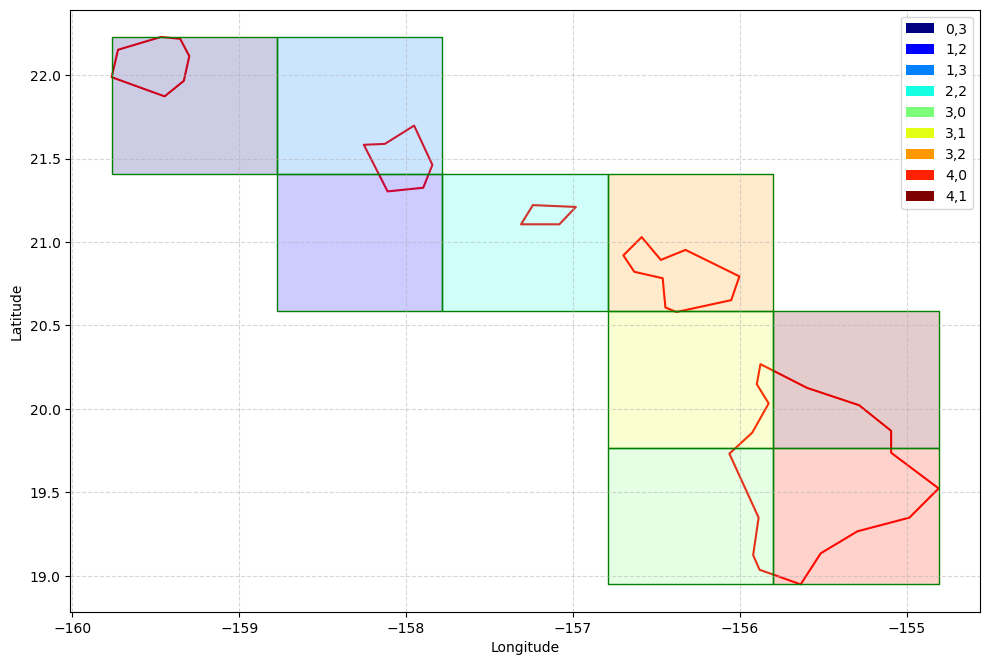

In [8]:
show_splitter(bbox_splitter, show_legend=True)

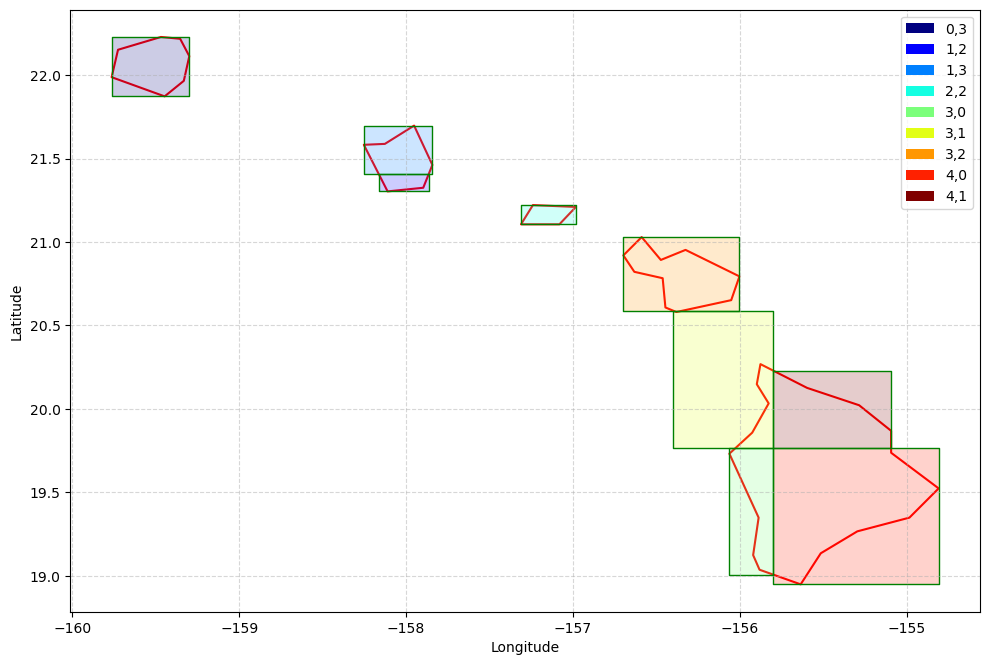

In [9]:
bbox_splitter_reduced = BBoxSplitter([hawaii_area], CRS.WGS84, (5, 4), reduce_bbox_sizes=True)

show_splitter(bbox_splitter_reduced, show_legend=True)

Using a finer grid can reduce the total extra area even further.

### Split the AOI Using the OSM Grid

In some workflows, it is useful to use a grid that stays fixed even if the AOI changes slightly.

`OsmSplitter` uses the [OpenStreetMap tile grid](https://wiki.openstreetmap.org/wiki/Slippy_Map).

In [10]:
osm_splitter = OsmSplitter([hawaii_area], CRS.WGS84, zoom_level=10)

print(repr(osm_splitter.get_bbox_list()[0]))
print(osm_splitter.get_info_list()[0])

BBox(((-159.96093749999997, 21.6165793367406), (-159.609375, 21.943045533438177)), crs=CRS('4326'))
{'zoom_level': 10, 'index_x': 57, 'index_y': 448}


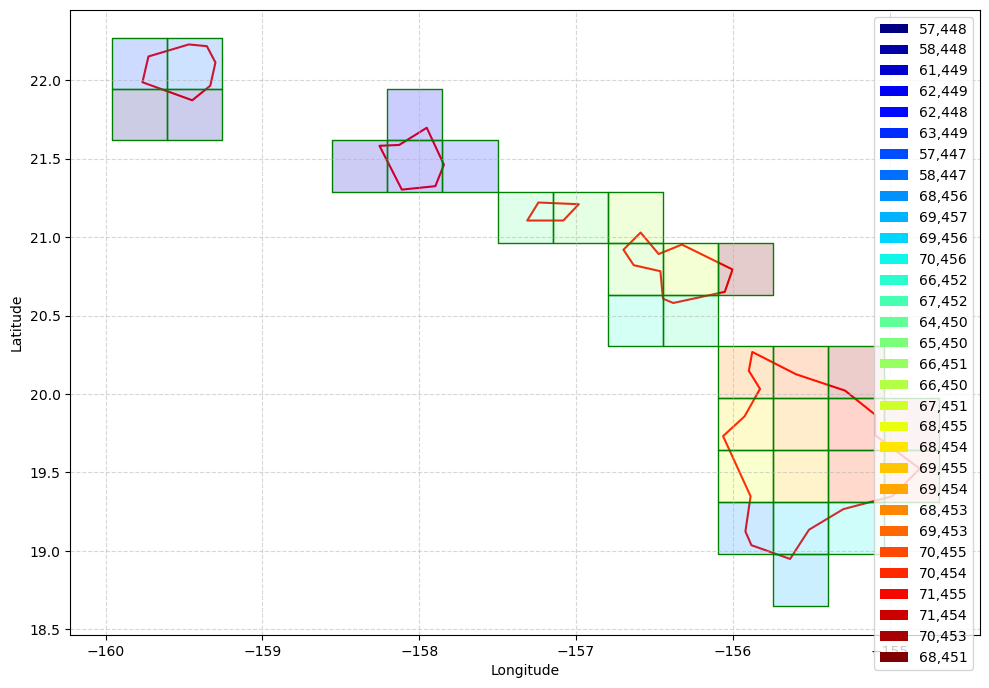

In [11]:
show_splitter(osm_splitter, show_legend=True)

### Split the AOI Using Satellite Tile Boundaries

If you want to work at the level of source satellite tiles, use `TileSplitter`. It works in combination with WFS service therefore an instance ID is required, as described in [Planet Authentication documentation](https://docs.planet.com/develop/authentication/). We also need to specify `time_interval` and `data_collection`.

In [12]:
if config.instance_id == "":
    print("Warning! To use WFS functionality, please configure the `instance_id`.")

Warning! To use WFS functionality, please configure the `instance_id`.


In [13]:
tile_splitter = TileSplitter(
    [hawaii_area], CRS.WGS84, ("2017-10-01", "2017-11-01"), data_collection=DataCollection.SENTINEL2_L1C, config=config
)

tile_bbox_list = tile_splitter.get_bbox_list()

print(len(tile_bbox_list))
print(tile_bbox_list[0].__repr__())
print(tile_splitter.get_info_list()[0])

16
BBox(((699960.0, 2290200.0), (809760.0, 2400000.0)), crs=CRS('32604'))
{'parent_bbox': BBox(((699960.0, 2290200.0), (809760.0, 2400000.0)), crs=CRS('32604')), 'index_x': 0, 'index_y': 0, 'ids': ['S2B_MSIL1C_20171028T210909_N0206_R057_T04QGJ_20171028T223108', 'S2A_MSIL1C_20171013T210921_N0205_R057_T04QGJ_20171013T210922', 'S2B_MSIL1C_20171008T210909_N0205_R057_T04QGJ_20171008T210909'], 'timestamps': [datetime.datetime(2017, 10, 28, 21, 9, 10, tzinfo=tzutc()), datetime.datetime(2017, 10, 13, 21, 9, 22, tzinfo=tzutc()), datetime.datetime(2017, 10, 8, 21, 9, 9, tzinfo=tzutc())]}


`TileSplitter` by default returns bounding boxes in the satellite tile CRS. In order to transform them we can use `BBox.transform(target_crs)` method or by specifying `crs` parameter in `get_bbox_list` method.

Note: This will only transform bounding box vertices and therefore the new bounding box will not be completely aligned with the original one. 

In [14]:
tile_splitter.get_bbox_list(crs=CRS.WGS84)[0]

BBox(((-157.08006491221116, 20.70062375217817), (-156.0067983462315, 21.676398866470976)), crs=CRS('4326'))

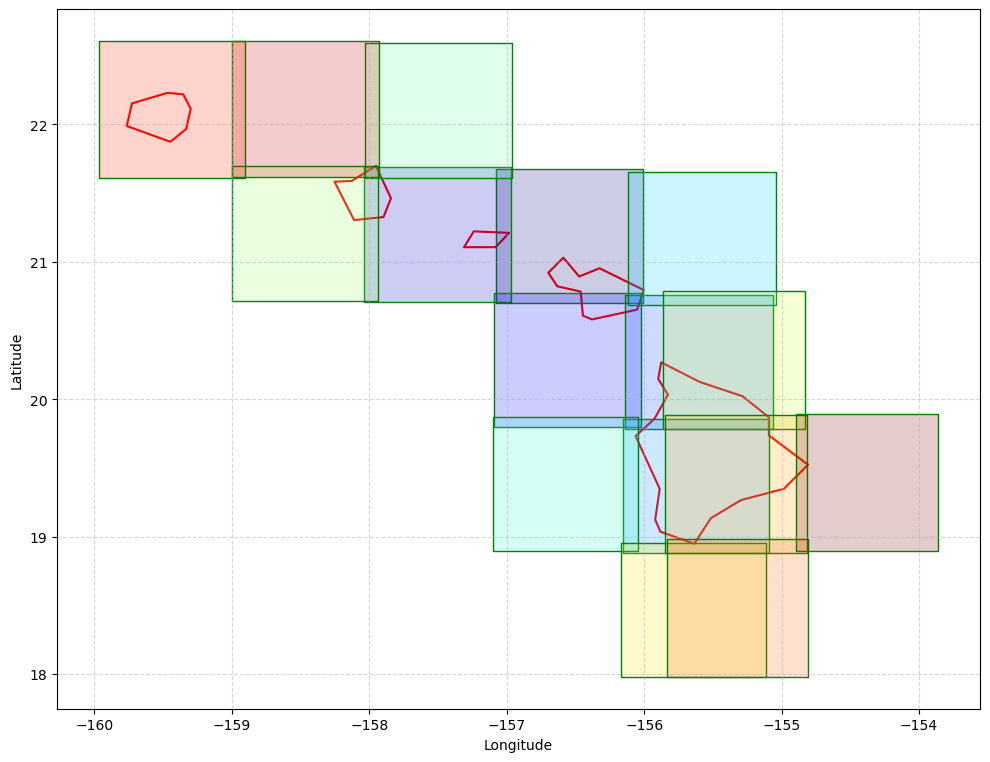

In [15]:
show_splitter(tile_splitter)

The resulting Sentinel-2 tiles can overlap. This splitter is most useful when you want to analyze data at the level of the original satellite tiles.

You can also split each satellite tile into smaller parts.

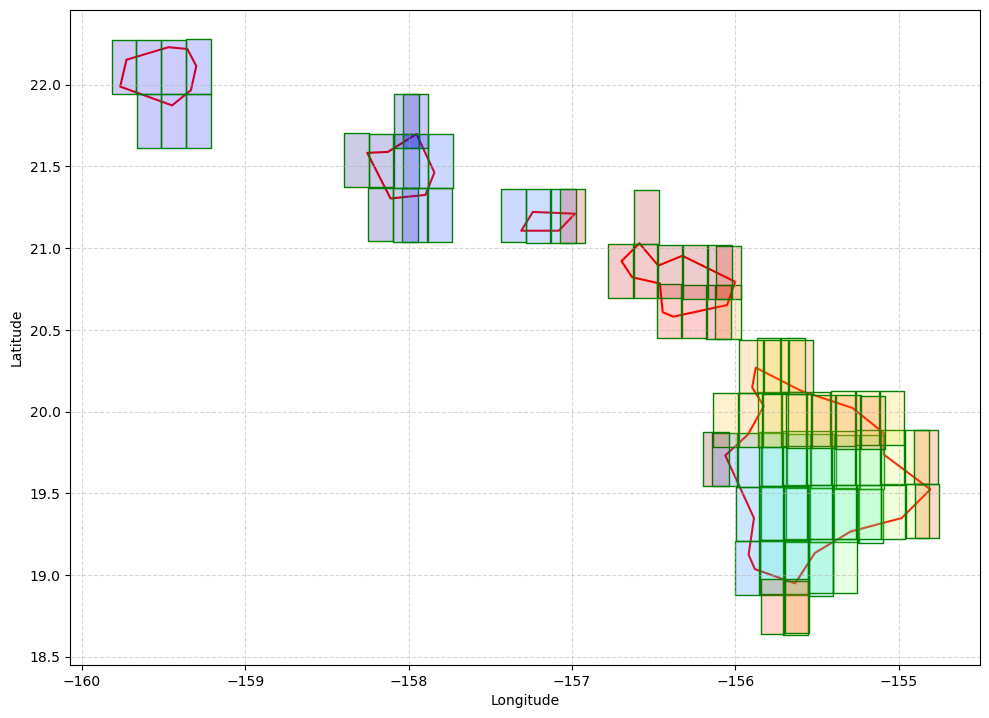

In [16]:
finer_tile_splitter = TileSplitter(
    [hawaii_area],
    CRS.WGS84,
    ("2017-10-01", "2018-03-01"),
    tile_split_shape=(7, 3),
    data_collection=DataCollection.SENTINEL2_L1C,
    config=config,
)

show_splitter(finer_tile_splitter, show_legend=False)

### Split the AOI Using a Custom Grid

If the built-in grid strategies do not match your workflow, use `CustomGridSplitter` to define your own grid from a list of bounding boxes.

The example below creates a simple grid based on integer latitude and longitude values.

In [17]:
bbox_grid = [BBox((x, y, x + 1, y + 1), CRS.WGS84) for x, y in itertools.product(range(-159, -155), range(18, 23))]

bbox_grid

[BBox(((-159.0, 18.0), (-158.0, 19.0)), crs=CRS('4326')),
 BBox(((-159.0, 19.0), (-158.0, 20.0)), crs=CRS('4326')),
 BBox(((-159.0, 20.0), (-158.0, 21.0)), crs=CRS('4326')),
 BBox(((-159.0, 21.0), (-158.0, 22.0)), crs=CRS('4326')),
 BBox(((-159.0, 22.0), (-158.0, 23.0)), crs=CRS('4326')),
 BBox(((-158.0, 18.0), (-157.0, 19.0)), crs=CRS('4326')),
 BBox(((-158.0, 19.0), (-157.0, 20.0)), crs=CRS('4326')),
 BBox(((-158.0, 20.0), (-157.0, 21.0)), crs=CRS('4326')),
 BBox(((-158.0, 21.0), (-157.0, 22.0)), crs=CRS('4326')),
 BBox(((-158.0, 22.0), (-157.0, 23.0)), crs=CRS('4326')),
 BBox(((-157.0, 18.0), (-156.0, 19.0)), crs=CRS('4326')),
 BBox(((-157.0, 19.0), (-156.0, 20.0)), crs=CRS('4326')),
 BBox(((-157.0, 20.0), (-156.0, 21.0)), crs=CRS('4326')),
 BBox(((-157.0, 21.0), (-156.0, 22.0)), crs=CRS('4326')),
 BBox(((-157.0, 22.0), (-156.0, 23.0)), crs=CRS('4326')),
 BBox(((-156.0, 18.0), (-155.0, 19.0)), crs=CRS('4326')),
 BBox(((-156.0, 19.0), (-155.0, 20.0)), crs=CRS('4326')),
 BBox(((-156.0

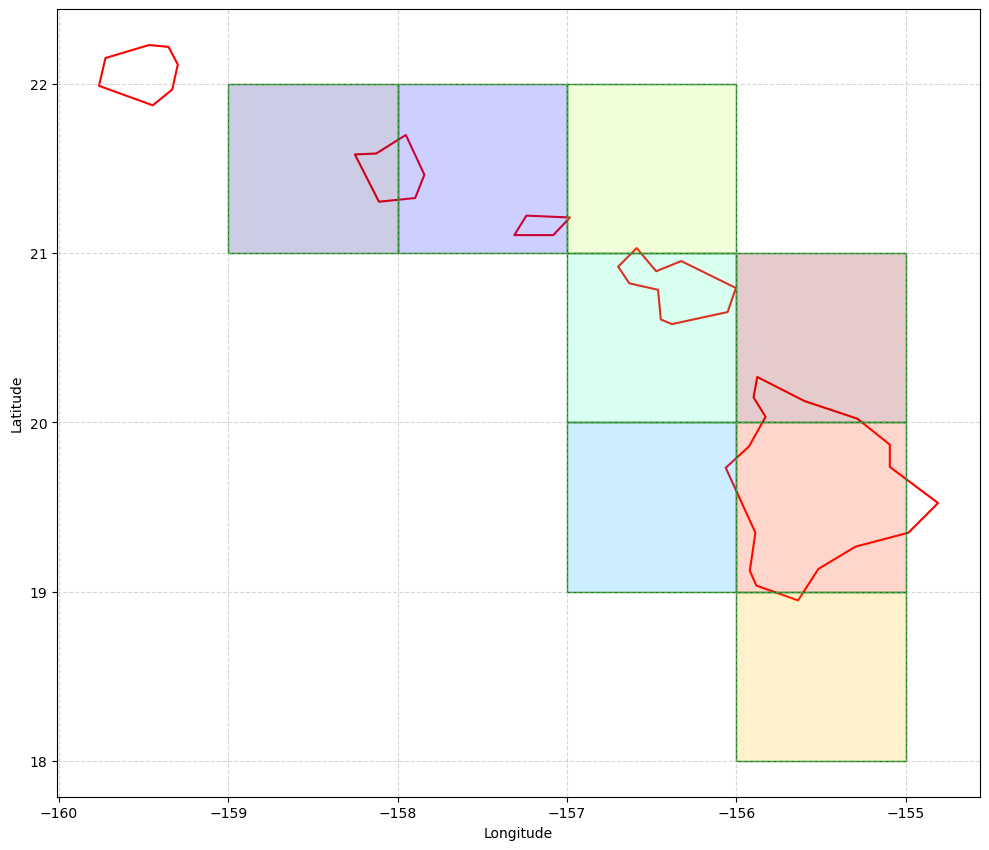

In [18]:
custom_grid_splitter = CustomGridSplitter([hawaii_area], CRS.WGS84, bbox_grid)

show_splitter(custom_grid_splitter)

Note that polygons, which are outside of the given collection of bounding boxes, will not affect the tiling.

Just like in previous examples we can further split each of the bounding boxes and reduce their size to better fit given shapes.

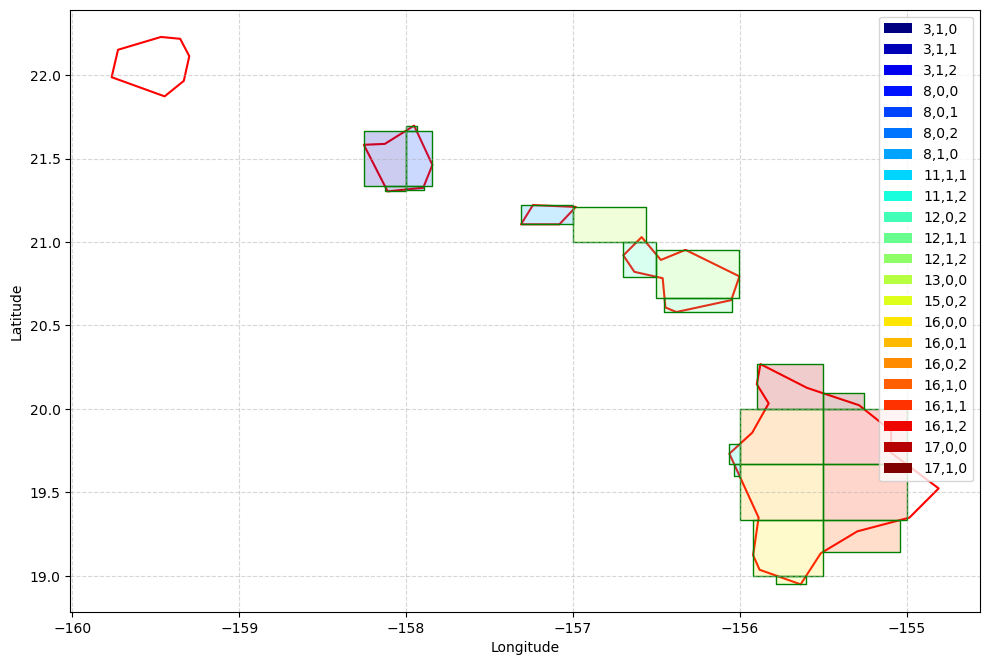

In [19]:
finer_custom_grid_splitter = CustomGridSplitter(
    [hawaii_area], CRS.WGS84, bbox_grid, bbox_split_shape=(2, 3), reduce_bbox_sizes=True
)

show_splitter(finer_custom_grid_splitter, show_legend=True)

### Split the AOI Across UTM Zones

For large areas that span multiple UTM zones, it can be useful to split the AOI by UTM zone or by UTM Military Grid Reference System.

`UtmZoneSplitter` and `UtmGridSplitter` return bounding boxes in UTM CRS. Each `BBox` uses the CRS of the UTM zone it belongs to.

Because these splitters use sizes defined in metres, `reduce_bbox_sizes` is not available for them. The two splitters return consistent results between each other, with the exceptions of areas where the UTM grid tiles present exceptions, as in `31V` and `32V`, and `31X`, `33X`, `35X` and `37X`. 

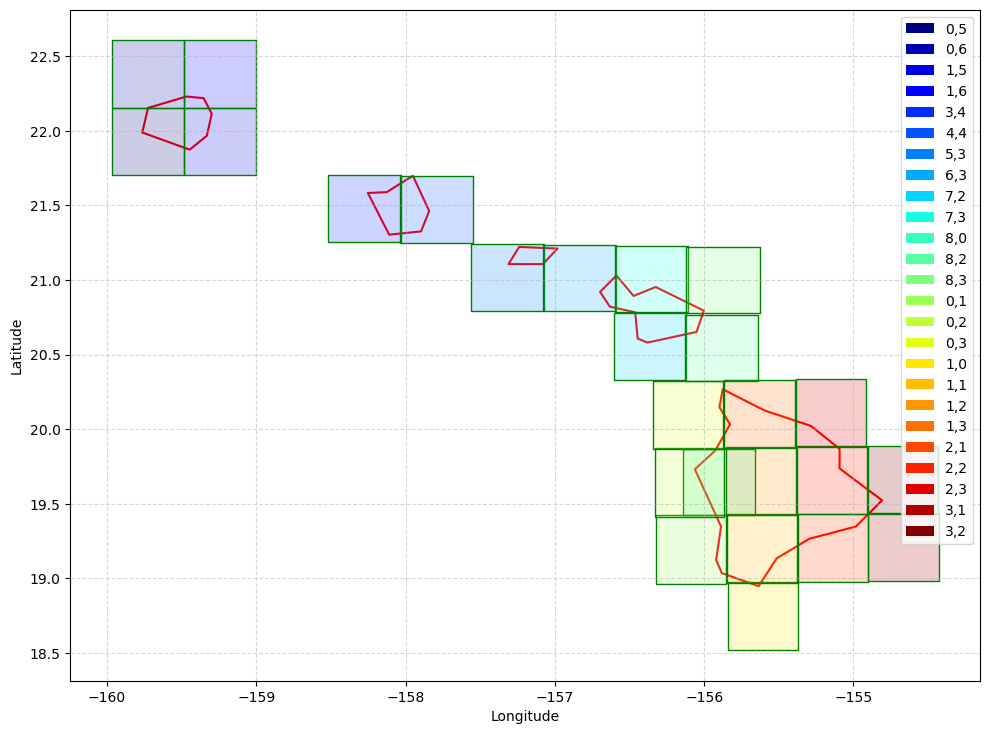

In [20]:
utm_zone_splitter = UtmZoneSplitter([hawaii_area], CRS.WGS84, (50000, 50000))

show_splitter(utm_zone_splitter, show_legend=True)

In [21]:
utm_zone_splitter.get_bbox_list()

[BBox(((400000.0, 2400000.0), (450000.0, 2450000.0)), crs=CRS('32604')),
 BBox(((400000.0, 2450000.0), (450000.0, 2500000.0)), crs=CRS('32604')),
 BBox(((450000.0, 2400000.0), (500000.0, 2450000.0)), crs=CRS('32604')),
 BBox(((450000.0, 2450000.0), (500000.0, 2500000.0)), crs=CRS('32604')),
 BBox(((550000.0, 2350000.0), (600000.0, 2400000.0)), crs=CRS('32604')),
 BBox(((600000.0, 2350000.0), (650000.0, 2400000.0)), crs=CRS('32604')),
 BBox(((650000.0, 2300000.0), (700000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((700000.0, 2300000.0), (750000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((750000.0, 2250000.0), (800000.0, 2300000.0)), crs=CRS('32604')),
 BBox(((750000.0, 2300000.0), (800000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2150000.0), (850000.0, 2200000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2250000.0), (850000.0, 2300000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2300000.0), (850000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((150000.0, 2100000.0), (200000.0, 2150000.0)

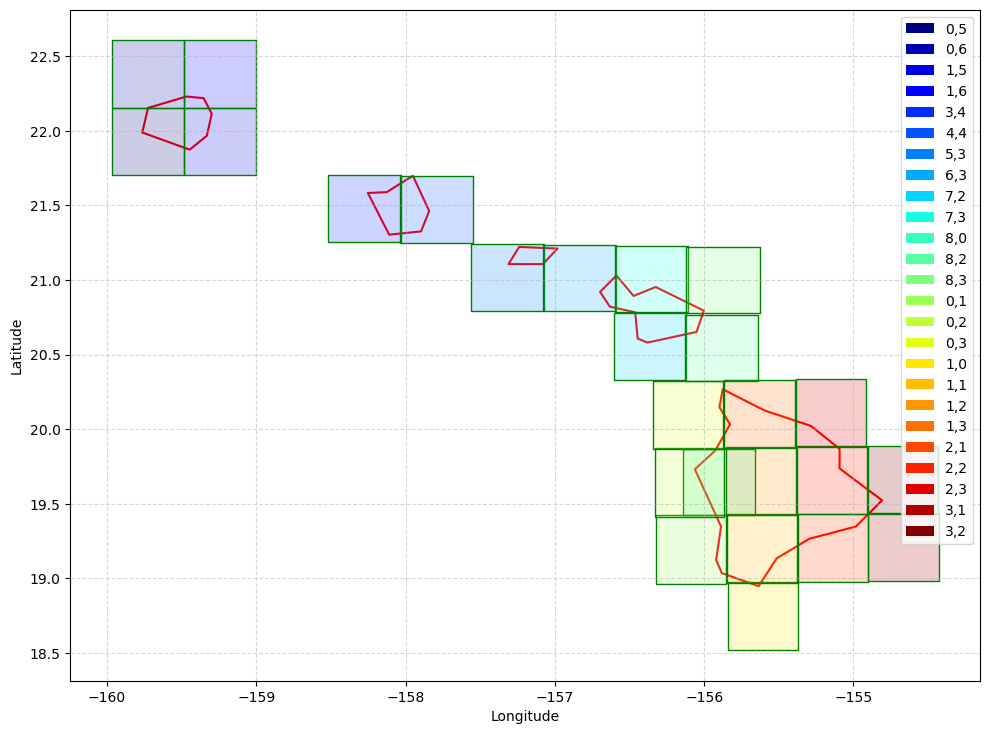

In [22]:
utm_grid_splitter = UtmGridSplitter([hawaii_area], CRS.WGS84, (50000, 50000))

show_splitter(utm_grid_splitter, show_legend=True)

### Download Data for Each Bounding Box

After splitting the AOI, you can create a request for each bounding box and download the results in parallel.

The example below uses Kauai, which is split into four bounding boxes, to demonstrate a multithreaded download workflow.

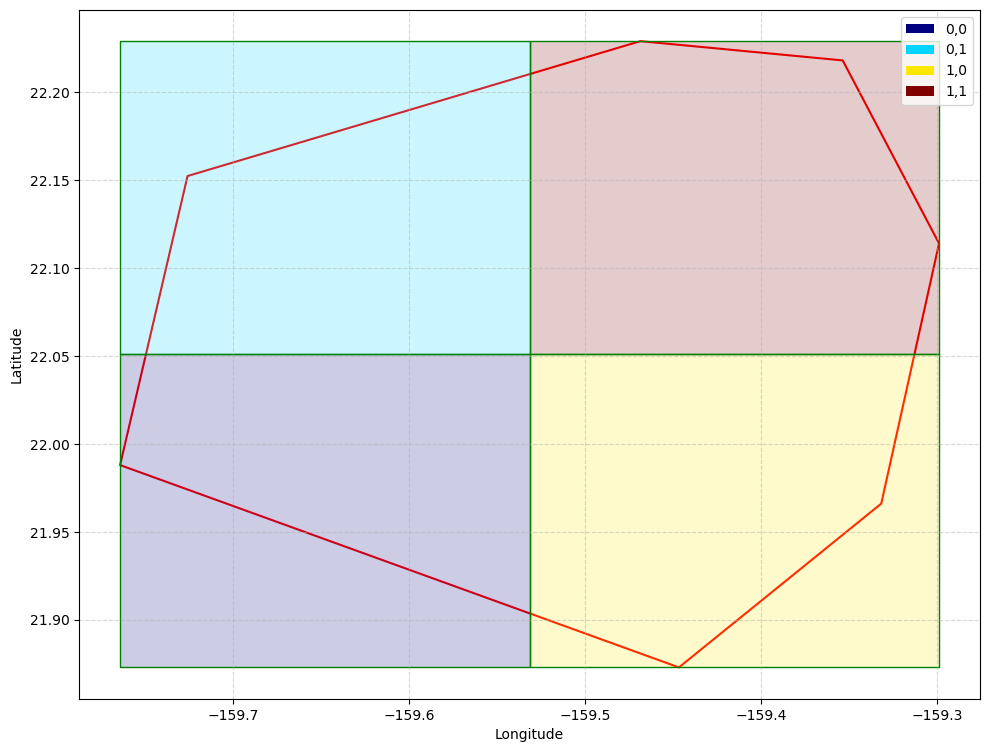

In [23]:
kauai = hawaii_area.geoms[-1]
kauai_split = BBoxSplitter([kauai], CRS.WGS84, (2, 2))
show_splitter(kauai_split, show_legend=True)

The example below uses an NDVI evalscript to request sample data.

In [24]:
ndvi_eval = """
//VERSION=3

function evaluatePixel(samples) {
    let val = index(samples.B08, samples.B04);
    return [val];
}

function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: {
      bands: 1
    }
  }
}
"""

The helper function below creates a `SentinelHubRequest` for a single bounding box. This is then applied to all bounding boxes, thus returning a list of `SentinelHubRequest`s each with a different specified bounding box.

The requested TIFF files are saved to a temporary folder, but you can change the output location if needed.

In [25]:
def get_subarea(bbox):
    return SentinelHubRequest(
        evalscript=ndvi_eval,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=("2024-10-01", "2025-04-01"),
                mosaicking_order=MosaickingOrder.LEAST_CC,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=(1250, 1250),
        data_folder=tempfile.gettempdir(),
        config=config,
    )

In [26]:
# create a list of requests
bbox_list = kauai_split.get_bbox_list()
sh_requests = [get_subarea(bbox) for bbox in bbox_list]
dl_requests = [request.download_list[0] for request in sh_requests]

# download data with multiple threads
downloaded_data = SentinelHubDownloadClient(config=config).download(dl_requests, max_threads=5)

After the download completes, collect the file paths for the downloaded tiles.

In [27]:
data_folder = sh_requests[0].data_folder
tiffs = [Path(data_folder) / req.get_filename_list()[0] for req in sh_requests]

Next, open the tiles with `rioxarray` and mosaic them into a single image for visualization.

For larger datasets, plotting can be slow and resource-intensive. In that case, consider using GDAL tools such as `gdalbuildvrt` and `gdaladdo` to create a virtual mosaic and overviews for faster display at different scales.

In [28]:
def plot_xr_and_bboxes(data_array, geo_vector=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    data_array.plot(ax=ax)
    ax.set_ylabel("Latitude")
    ax.set_xlabel("Longitude")
    ax.set_aspect(1)
    if geo_vector is not None:
        geo_vector.plot(ax=ax, edgecolor="red", facecolor="none")
    plt.show()

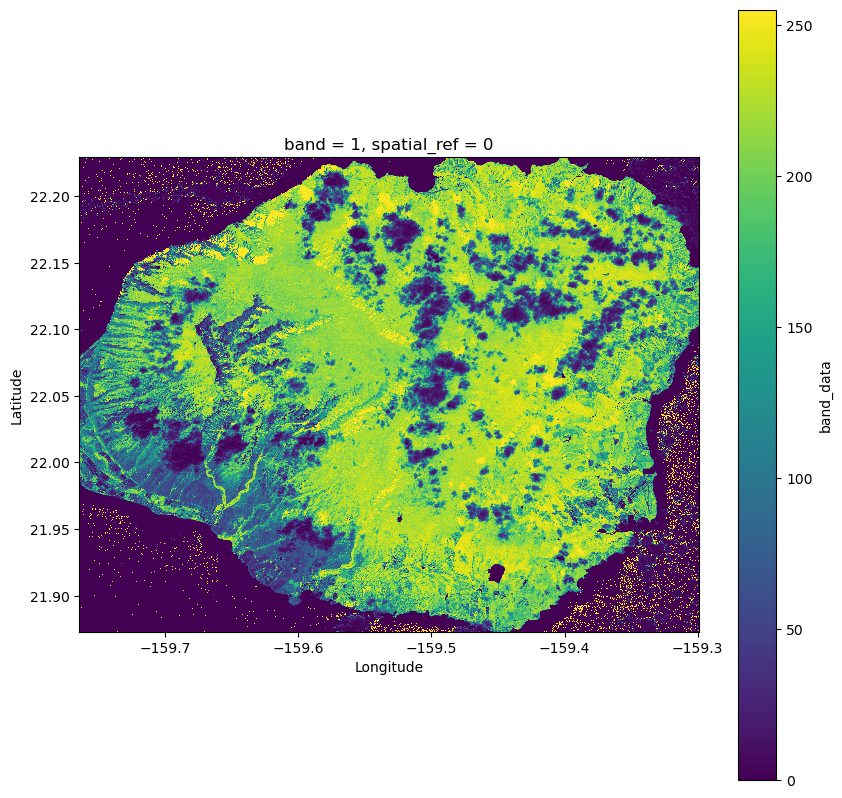

In [29]:
import rioxarray
import xarray as xr

composed_tiff = xr.open_mfdataset(tiffs, engine="rasterio")
composed_map = composed_tiff.band_data.isel(band=0)

plot_xr_and_bboxes(composed_map)

Finally to visualize the bounding boxes as well we can draw the original bounding boxes over our raster.

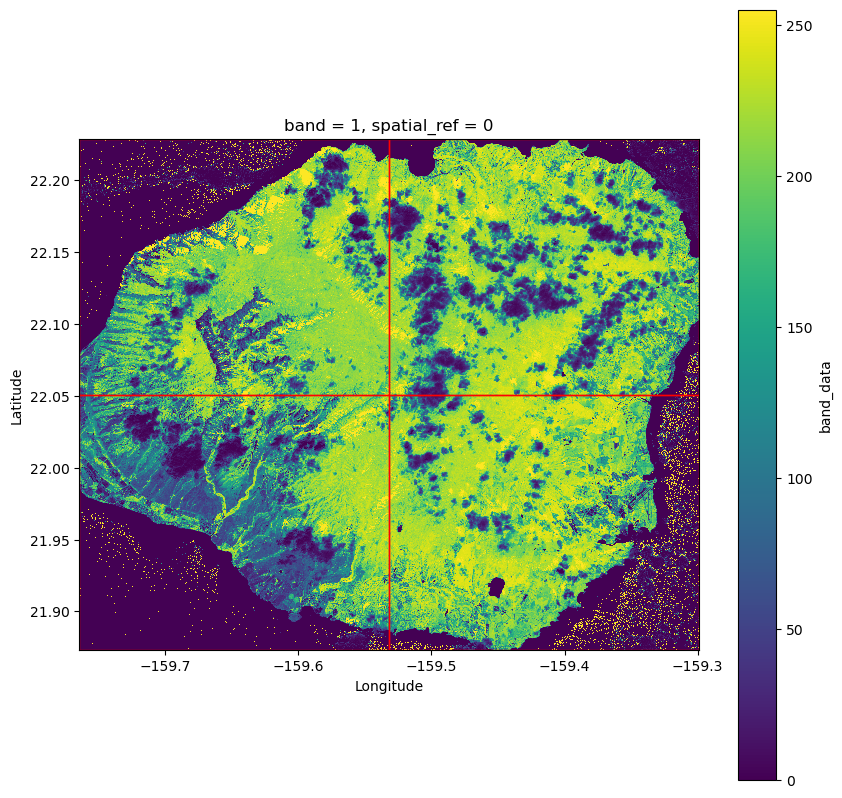

In [30]:
kauai_gpd = gpd.GeoDataFrame(geometry=[box(*bbox) for bbox in bbox_list], crs=4326)
plot_xr_and_bboxes(composed_tiff.band_data, kauai_gpd)

These tiles can also be used in downstream workflows with tools such as [eo-learn](https://eo-learn.readthedocs.io/en/latest/). For example, you can ingest them with [ImportFromTiffTask](https://eo-learn.readthedocs.io/en/latest/reference/eolearn.io.raster_io.html#eolearn.io.raster_io.ImportFromTiffTask).

This pattern is useful for larger Earth observation workflows where you need to process data in smaller, more manageable chunks.